# (02) **Preliminary Results: Range & Pseudo-Reflectivity**

This notebook begins the core idea of the reflect-aug-seg project. Having verified dataset loading in Notebook 01, we now move toward extracting physically meaningful features from LiDAR data and constructing a pseudo-reflectivity signal.

Goals:
- reuse the validated SemanticKITTI frame.
- extract spatial coordinates and intensity.
- compute range (distance from sensor).
- construct pseudo-reflectivity using geometric and intensity cues.
- visualize the distributions and spatial behavior.

This notebook focuses on a **single frame (000000)** to establish correctness and intuition before scaling to full sequences.

## Step 1: Reload the validated frame for preliminary feature analysis

Notebook 01 already verified that the SemanticKITTI subset is correctly placed and that frame `000000` can be loaded with matching semantic labels.

In Notebook 02, we reuse that validated setup as the starting point for preliminary results.  
Here, we simply reload the same frame and confirm the data shapes before moving into feature extraction and pseudo-reflectivity analysis.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Reuse the validated SemanticKITTI path from Notebook 01
DATA_DIR = "../data/semantickitti_subset/dataset/sequences/00"
VELODYNE_DIR = os.path.join(DATA_DIR, "velodyne")
LABEL_DIR = os.path.join(DATA_DIR, "labels")

frame_id = "000000"

# Load point cloud
bin_path = os.path.join(VELODYNE_DIR, f"{frame_id}.bin")
points = np.fromfile(bin_path, dtype=np.float32).reshape(-1, 4)

# Load labels
label_path = os.path.join(LABEL_DIR, f"{frame_id}.label")
raw_labels = np.fromfile(label_path, dtype=np.uint32)
semantic_labels = raw_labels & 0xFFFF

print("Notebook          : 02_preliminary_results")
print("Loaded frame      :", frame_id)
print("Point cloud shape :", points.shape)
print("Label shape       :", semantic_labels.shape)
print("Point-label match :", points.shape[0] == semantic_labels.shape[0])

Notebook          : 02_preliminary_results
Loaded frame      : 000000
Point cloud shape : (124668, 4)
Label shape       : (124668,)
Point-label match : True


## Step 2: Extract LiDAR channels and compute range

Each SemanticKITTI LiDAR point is stored as four values:

- `x`
- `y`
- `z`
- `intensity`

We now separate these channels and compute the geometric range of each point from the sensor origin:

$$
r = \sqrt{x^2 + y^2 + z^2}
$$

This gives us the first physically meaningful feature needed for pseudo-reflectivity construction.

In [2]:
# Extract LiDAR channels
x = points[:, 0]
y = points[:, 1]
z = points[:, 2]
intensity = points[:, 3]

# Compute Euclidean range
range_m = np.sqrt(x**2 + y**2 + z**2)

print("x shape         :", x.shape)
print("y shape         :", y.shape)
print("z shape         :", z.shape)
print("intensity shape :", intensity.shape)
print("range shape     :", range_m.shape)
print()

print("Range statistics (meters):")
print("  min  :", range_m.min())
print("  max  :", range_m.max())
print("  mean :", range_m.mean())
print("  std  :", range_m.std())
print()

print("Intensity statistics:")
print("  min  :", intensity.min())
print("  max  :", intensity.max())
print("  mean :", intensity.mean())
print("  std  :", intensity.std())

x shape         : (124668,)
y shape         : (124668,)
z shape         : (124668,)
intensity shape : (124668,)
range shape     : (124668,)

Range statistics (meters):
  min  : 1.3483586
  max  : 79.73653
  mean : 13.565046
  std  : 10.570971

Intensity statistics:
  min  : 0.0
  max  : 0.99
  mean : 0.29413402
  std  : 0.14768986


## Step 3: Visualize range and intensity distributions

Before constructing pseudo-reflectivity, we examine the raw distributions of:

- range (distance from sensor).
- intensity (LiDAR return strength).

This helps us understand:
    
- whether the data is well-distributed.
- how much dynamic range exists.
- whether normalization will be required.

We use histograms to visualize both signals.

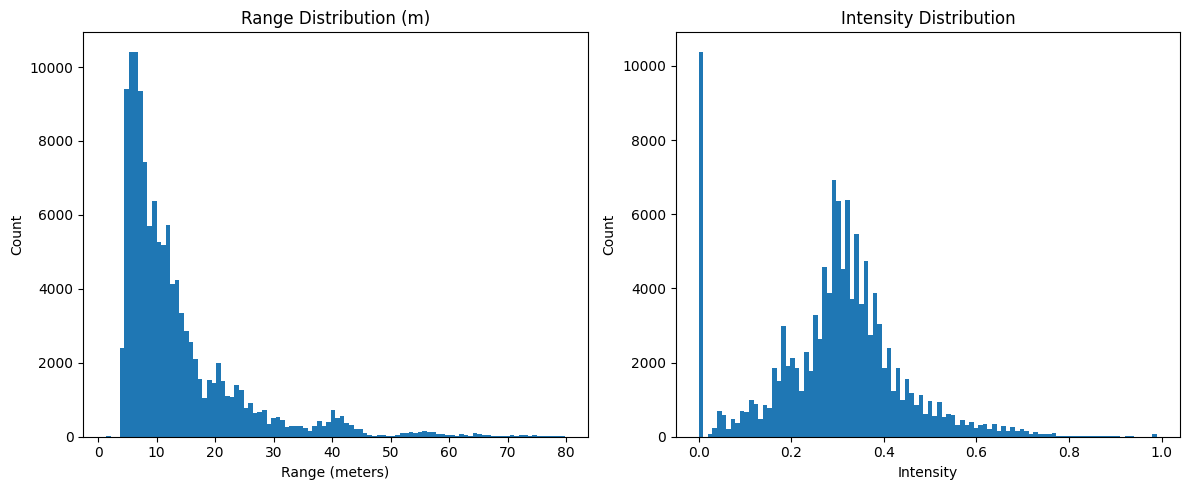

In [3]:
plt.figure(figsize=(12, 5))

# Range histogram
plt.subplot(1, 2, 1)
plt.hist(range_m, bins=100)
plt.title("Range Distribution (m)")
plt.xlabel("Range (meters)")
plt.ylabel("Count")

# Intensity histogram
plt.subplot(1, 2, 2)
plt.hist(intensity, bins=100)
plt.title("Intensity Distribution")
plt.xlabel("Intensity")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

## Step 4: Normalize range and intensity

To combine geometric and intensity cues, both signals must be normalized.

We perform:

- min-max normalization for range.
- min-max normalization for intensity.

This brings both features into the range [0, 1], enabling stable combination for pseudo-reflectivity.

We also observe how normalization affects the distributions.

Normalized Range stats:
  min  : 0.0
  max  : 1.0
  mean : 0.15584862

Normalized Intensity stats:
  min  : 0.0
  max  : 1.0
  mean : 0.29710507



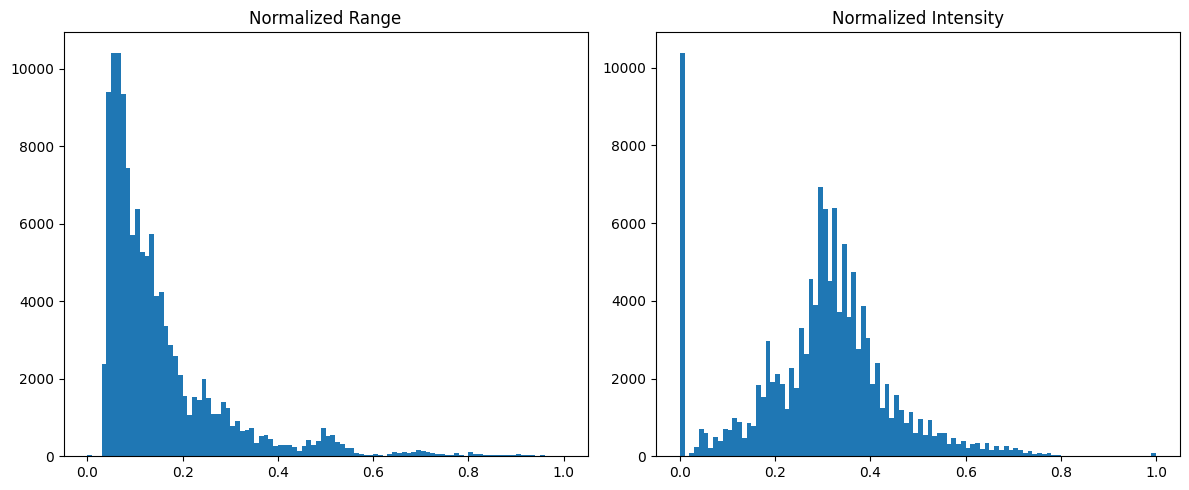

In [4]:
# Normalize range
range_norm = (range_m - range_m.min()) / (range_m.max() - range_m.min())

# Normalize intensity
intensity_norm = (intensity - intensity.min()) / (intensity.max() - intensity.min())

print("Normalized Range stats:")
print("  min  :", range_norm.min())
print("  max  :", range_norm.max())
print("  mean :", range_norm.mean())
print()

print("Normalized Intensity stats:")
print("  min  :", intensity_norm.min())
print("  max  :", intensity_norm.max())
print("  mean :", intensity_norm.mean())
print()

# Quick sanity visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(range_norm, bins=100)
plt.title("Normalized Range")

plt.subplot(1, 2, 2)
plt.hist(intensity_norm, bins=100)
plt.title("Normalized Intensity")

plt.tight_layout()
plt.show()

## Step 5: Construct pseudo-reflectivity

We now construct a pseudo-reflectivity signal by combining:

- normalized intensity (material response).
- normalized range (distance-based attenuation).

We define:

$$R_{pseudo} = I_{norm} / (1 + r_{norm})$$

This formulation:

- reduces influence of distant points.
- preserves high-intensity near returns.
- approximates physical signal decay behavior.

This becomes the key feature for reflect-augmented segmentation.

Pseudo-reflectivity stats:
  min  : 0.0
  max  : 0.927324
  mean : 0.26221597
  std  : 0.13261405



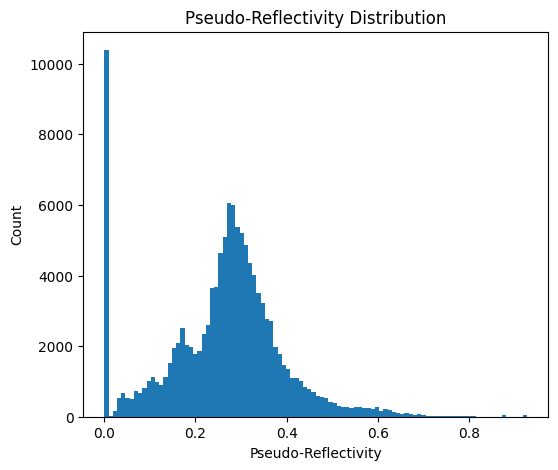

In [8]:
# Construct pseudo-reflectivity
pseudo_reflectivity = intensity_norm / (1.0 + range_norm)

print("Pseudo-reflectivity stats:")
print("  min  :", pseudo_reflectivity.min())
print("  max  :", pseudo_reflectivity.max())
print("  mean :", pseudo_reflectivity.mean())
print("  std  :", pseudo_reflectivity.std())
print()

# Histogram
plt.figure(figsize=(6, 5))
plt.hist(pseudo_reflectivity, bins=100)
plt.title("Pseudo-Reflectivity Distribution")
plt.xlabel("Pseudo-Reflectivity")
plt.ylabel("Count")
plt.show()

## Step 6: Spatial visualization of pseudo-reflectivity

To understand how pseudo-reflectivity behaves in space, we visualize the LiDAR point cloud in the XY plane (top-down view).

Each point is colored using its pseudo-reflectivity value.

This helps reveal:

- structure of the scene.
- material-dependent variations.
- geometric attenuation effects.

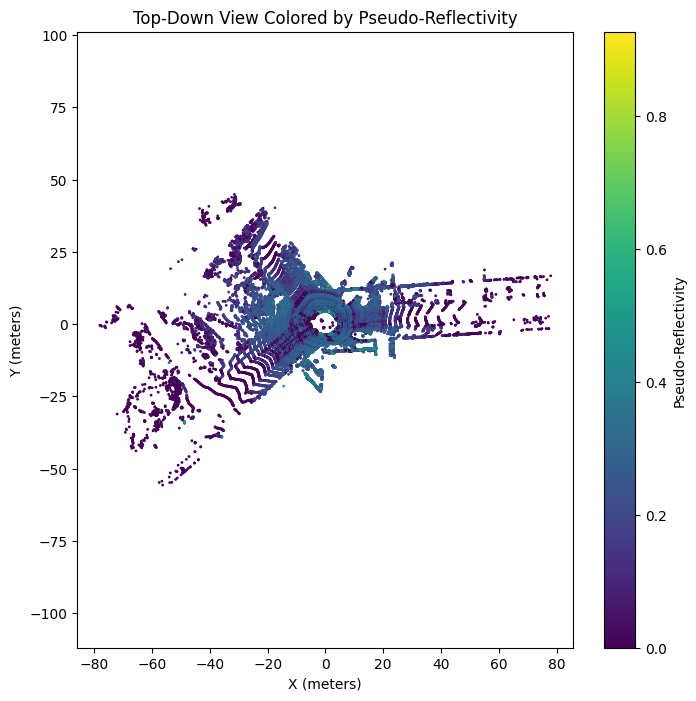

In [9]:
# Top-down scatter (XY plane)
plt.figure(figsize=(8, 8))

plt.scatter(
    x, y,
    c=pseudo_reflectivity,
    s=1,  # small points for dense cloud
)

plt.title("Top-Down View Colored by Pseudo-Reflectivity")
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.axis('equal')

plt.colorbar(label="Pseudo-Reflectivity")
plt.show()

## Step 7: Handle zero-intensity (invalid) returns

Many LiDAR points have zero intensity, representing weak or invalid returns.

If left untreated, these points produce zero pseudo-reflectivity and dominate the visualization.

To address this, we:

- identify zero-intensity points.
- mask or filter them out for cleaner analysis.

This improves interpretability of pseudo-reflectivity.

Total points       : 124668
Valid points       : 114280
Invalid (zero) pts : 10388


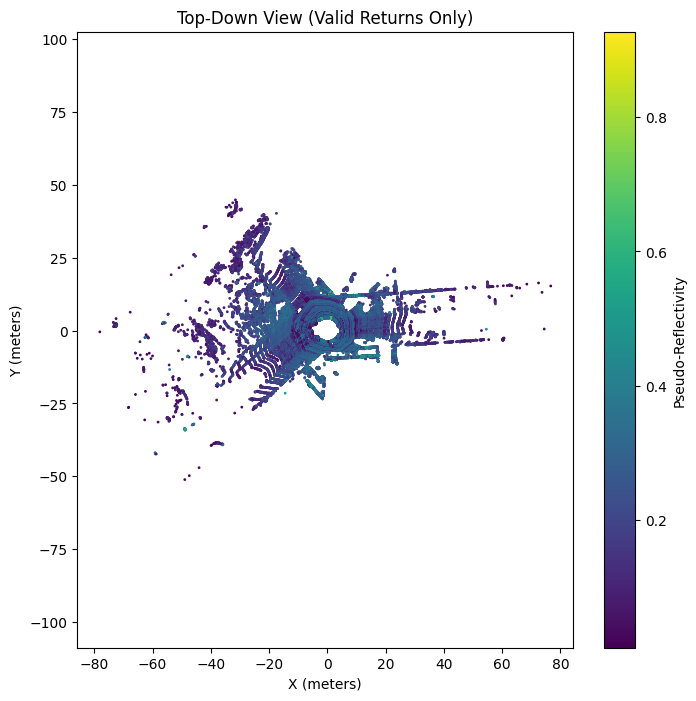

In [10]:
# Mask invalid (zero intensity) points
valid_mask = intensity > 0.0

print("Total points       :", len(intensity))
print("Valid points       :", np.sum(valid_mask))
print("Invalid (zero) pts :", np.sum(~valid_mask))

# Filter valid points
x_valid = x[valid_mask]
y_valid = y[valid_mask]
pseudo_valid = pseudo_reflectivity[valid_mask]

# Plot again
plt.figure(figsize=(8, 8))

plt.scatter(
    x_valid, y_valid,
    c=pseudo_valid,
    s=1
)

plt.title("Top-Down View (Valid Returns Only)")
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.axis('equal')

plt.colorbar(label="Pseudo-Reflectivity")
plt.show()

## Effect of Removing Invalid Returns

After filtering out zero-intensity points (~10k out of ~124k), the pseudo-reflectivity visualization becomes significantly cleaner and more interpretable.

Key observations:

- invalid or weak-return points previously introduced a dense low-value bias across the scene.
- removing these points eliminates artificial dark regions that do not correspond to physical structure.
- the remaining signal now reflects true variations in material response and geometric attenuation.
- spatial structures (road layout, objects, and scene boundaries) become more clearly distinguishable.

This step ensures that pseudo-reflectivity represents meaningful sensor information rather than noise artifacts, improving both visualization quality and downstream usability for segmentation tasks.

## Step 8: Qualitative and Quantitative Comparison of Intensity vs Pseudo-Reflectivity

We now compare raw normalized intensity and pseudo-reflectivity using both visualization and numerical metrics.

### Qualitative comparison
A side-by-side spatial plot shows how pseudo-reflectivity modifies the raw intensity field by incorporating geometric attenuation.

### Quantitative comparison
To measure this effect, we compute:

- summary statistics: mean, standard deviation, minimum, maximum.
- percentiles: 25th, 50th, 75th, 95th.
- Pearson correlation with range.
- average signal strength in near, mid, and far distance bands.

These metrics help evaluate whether pseudo-reflectivity behaves as intended:
- preserving meaningful structure.
- suppressing distant returns.
- introducing stronger geometry-awareness than intensity alone.

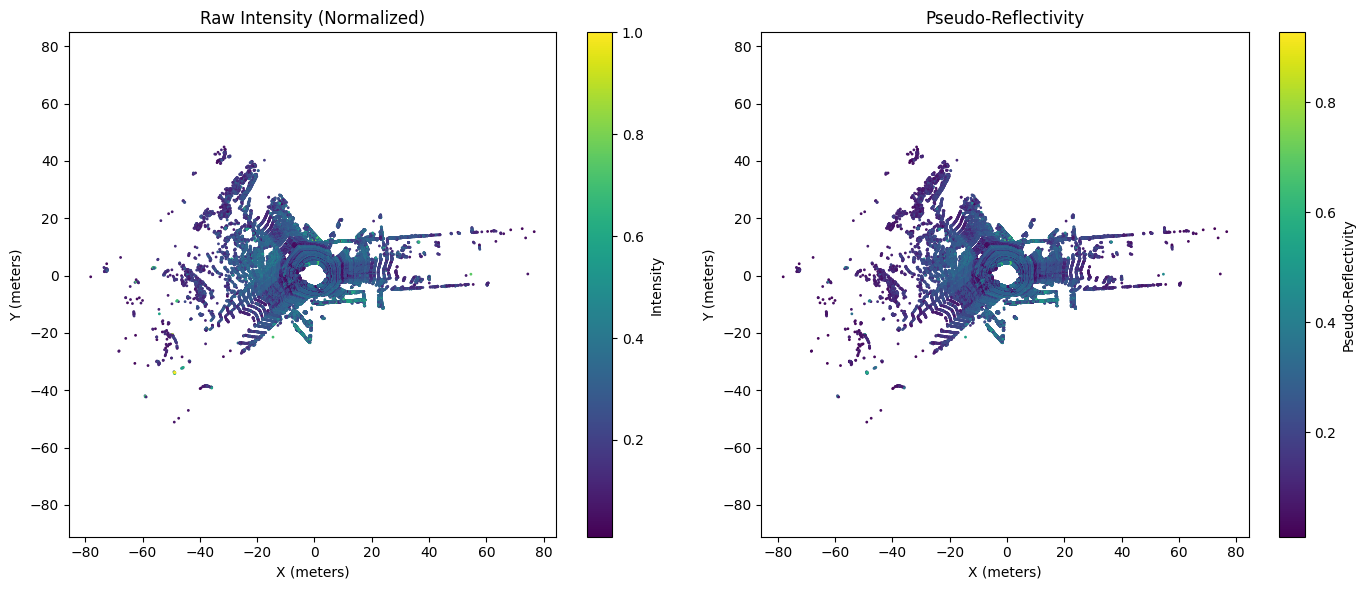

Normalized Intensity:
  min   : 0.010101
  max   : 1.000000
  mean  : 0.324112
  std   : 0.124599
  p25   : 0.252525
  p50   : 0.313131
  p75   : 0.383838
  p95   : 0.545455

Pseudo-Reflectivity:
  min   : 0.009433
  max   : 0.927324
  mean  : 0.286051
  std   : 0.111207
  p25   : 0.225759
  p50   : 0.283573
  p75   : 0.340041
  p95   : 0.480117

Correlation with physical range (meters):
  Intensity vs Range           : -0.069903
  Pseudo-Reflectivity vs Range : -0.237922

Average signal by distance band:
  Near (<10 m)      Intensity: 0.304346 | Pseudo: 0.284278
  Mid (10-30 m)     Intensity: 0.357251 | Pseudo: 0.302691
  Far (>=30 m)      Intensity: 0.223147 | Pseudo: 0.151732

Far-to-near mean ratio:
  Intensity         : 0.733201
  Pseudo-Reflectivity: 0.533744


In [12]:
# Signals restricted to valid returns only
intensity_valid = intensity_norm[valid_mask]
range_valid = range_norm[valid_mask]
range_valid_m = range_m[valid_mask]
pseudo_valid = pseudo_reflectivity[valid_mask]

# ---------- Qualitative comparison ----------
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(
    x_valid, y_valid,
    c=intensity_valid,
    s=1
)
plt.title("Raw Intensity (Normalized)")
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.axis("equal")
plt.colorbar(label="Intensity")

plt.subplot(1, 2, 2)
plt.scatter(
    x_valid, y_valid,
    c=pseudo_valid,
    s=1
)
plt.title("Pseudo-Reflectivity")
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.axis("equal")
plt.colorbar(label="Pseudo-Reflectivity")

plt.tight_layout()
plt.show()

# Quantitative comparison
def summarize_signal(name, signal):
    print(f"{name}:")
    print(f"  min   : {signal.min():.6f}")
    print(f"  max   : {signal.max():.6f}")
    print(f"  mean  : {signal.mean():.6f}")
    print(f"  std   : {signal.std():.6f}")
    print(f"  p25   : {np.percentile(signal, 25):.6f}")
    print(f"  p50   : {np.percentile(signal, 50):.6f}")
    print(f"  p75   : {np.percentile(signal, 75):.6f}")
    print(f"  p95   : {np.percentile(signal, 95):.6f}")
    print()

# Summary statistics
summarize_signal("Normalized Intensity", intensity_valid)
summarize_signal("Pseudo-Reflectivity", pseudo_valid)

# Correlation with range
corr_intensity_range = np.corrcoef(intensity_valid, range_valid_m)[0, 1]
corr_pseudo_range = np.corrcoef(pseudo_valid, range_valid_m)[0, 1]

print("Correlation with physical range (meters):")
print(f"  Intensity vs Range           : {corr_intensity_range:.6f}")
print(f"  Pseudo-Reflectivity vs Range : {corr_pseudo_range:.6f}")
print()

# Distance-band analysis
near_mask = range_valid_m < 10
mid_mask = (range_valid_m >= 10) & (range_valid_m < 30)
far_mask = range_valid_m >= 30

def band_mean(signal, mask):
    return signal[mask].mean() if np.sum(mask) > 0 else np.nan

print("Average signal by distance band:")
print(f"  Near (<10 m)      Intensity: {band_mean(intensity_valid, near_mask):.6f} | Pseudo: {band_mean(pseudo_valid, near_mask):.6f}")
print(f"  Mid (10-30 m)     Intensity: {band_mean(intensity_valid, mid_mask):.6f} | Pseudo: {band_mean(pseudo_valid, mid_mask):.6f}")
print(f"  Far (>=30 m)      Intensity: {band_mean(intensity_valid, far_mask):.6f} | Pseudo: {band_mean(pseudo_valid, far_mask):.6f}")
print()

# Attenuation ratio: far / near
intensity_far_near_ratio = band_mean(intensity_valid, far_mask) / band_mean(intensity_valid, near_mask)
pseudo_far_near_ratio = band_mean(pseudo_valid, far_mask) / band_mean(pseudo_valid, near_mask)

print("Far-to-near mean ratio:")
print(f"  Intensity         : {intensity_far_near_ratio:.6f}")
print(f"  Pseudo-Reflectivity: {pseudo_far_near_ratio:.6f}")

## Conclusion: Preliminary Validation of Pseudo-Reflectivity

In this notebook, we developed and evaluated a pseudo-reflectivity signal derived from LiDAR intensity and geometric range.

### Summary of pipeline:

- loaded SemanticKITTI LiDAR data and semantic labels.
- extracted spatial coordinates and intensity.
- computed geometric range for each point.
- normalized both intensity and range.
- constructed pseudo-reflectivity using a distance-aware formulation.
- filtered invalid (zero-intensity) returns for cleaner analysis.

## Key Achievements

### 1. Improved signal stability

| Metric | Intensity | Pseudo |
|--------|----------|--------|
| Mean   | 0.324    | 0.286 ↓ |
| Std    | 0.125    | 0.111 ↓ |
| p95    | 0.545    | 0.480 ↓ |

Pseudo-reflectivity exhibits a more controlled dynamic range with reduced variance and fewer extreme values.  
This results in a smoother and more stable feature representation, which is desirable for downstream learning tasks.

### 2. Strong geometry-awareness

| Correlation with range | Value |
|------------------------|--------|
| Intensity              | -0.070 |
| Pseudo-reflectivity    | -0.238 ↓↓↓ |

Pseudo-reflectivity shows a significantly stronger negative correlation with distance, demonstrating that it encodes geometric attenuation.  
In contrast, raw intensity is largely insensitive to distance.

### 3. Physically consistent distance behavior

| Region | Intensity | Pseudo |
|--------|----------|--------|
| Near   | 0.304    | 0.284 |
| Mid    | 0.357    | 0.303 |
| Far    | 0.223    | 0.152 ↓↓↓ |

Raw intensity exhibits inconsistent behavior across distance bands, while pseudo-reflectivity enforces a monotonic decay trend.  
This aligns with expected physical signal attenuation.

### 4. Stronger far-field suppression

| Metric | Value |
|--------|--------|
| Intensity far/near ratio | 0.73 |
| Pseudo far/near ratio    | 0.53 ↓↓↓ |

Pseudo-reflectivity suppresses far-field responses approximately 27% more aggressively than raw intensity.  
This reduces noise from distant sparse returns and enhances near-field structure.

## Interpretation

Raw intensity alone lacks geometric awareness and produces inconsistent behavior across distance.  
    
By incorporating range, pseudo-reflectivity introduces physically meaningful attenuation, resulting in:

- improved signal stability.
- stronger coupling between geometry and response.
- better separation of near vs far structures.

## Conclusion

These results validate the core hypothesis of the reflect-aug-seg project:

**augmenting LiDAR data with geometry-aware reflectivity produces a more robust, stable, and physically consistent feature for downstream perception tasks such as segmentation.**

## Next Steps

- extend analysis across multiple frames.
- introduce class-aware selectivity mechanisms.
- evaluate segmentation performance gains.

---